# Actividad 3: Reducción de dimensionalidad y clustering

## 1. Selección del dataset

Dataset elegido: **Human Activity Recognition Using Smartphones** (UCI). 30 personas realizaron 6 actividades con un smartphone en la cintura; cada fila es una ventana de 2,56 s descripta por 561 features del acelerómetro y el giroscopio.

Es un problema de **clasificación** (`WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS`, `SITTING`, `STANDING`, `LAYING`). La etiqueta solo se usa al final, para interpretar.

**Hipótesis**

1. La separación principal será entre actividades **dinámicas** (caminar, escaleras) y **estáticas** (sentado, parado, acostado).
2. `LAYING` se separará bien por la orientación del teléfono; `SITTING` y `STANDING` se van a mezclar.
3. Las tres formas de caminar se van a mezclar entre sí.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, adjusted_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram
import umap
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

### Descarga de los datos

El dataset (~60 MB) no se versiona: se descarga desde UCI la primera vez que se ejecuta la notebook.

In [2]:
DATA_DIR = Path('data')
HAR_DIR = DATA_DIR / 'UCI HAR Dataset'
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'

if not HAR_DIR.exists():
    zip_externo = DATA_DIR / 'har.zip'
    urllib.request.urlretrieve(URL, zip_externo)
    with zipfile.ZipFile(zip_externo) as z:
        z.extract('UCI HAR Dataset.zip', DATA_DIR)
    with zipfile.ZipFile(DATA_DIR / 'UCI HAR Dataset.zip') as z:
        z.extractall(DATA_DIR, members=[m for m in z.namelist() if not m.startswith('__MACOSX')])
    zip_externo.unlink()
    (DATA_DIR / 'UCI HAR Dataset.zip').unlink()

print(sorted(p.name for p in HAR_DIR.iterdir() if not p.name.startswith('.')))

['README.txt', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


El dataset viene separado en train/test. Como no hay entrenamiento supervisado, se unen ambas partes (10.299 ventanas).

In [3]:
features = pd.read_csv(HAR_DIR / 'features.txt', sep=r'\s+', header=None, names=['idx', 'nombre'])
actividades = pd.read_csv(HAR_DIR / 'activity_labels.txt', sep=r'\s+', header=None,
                          names=['id', 'actividad']).set_index('id')['actividad']

# Hay nombres de features repetidos (las bandas de frecuencia bandsEnergy se repiten por eje): se les agrega el índice
nombres = features['nombre'].where(~features['nombre'].duplicated(keep=False),
                                   features['nombre'] + '_' + features['idx'].astype(str))

def cargar(split):
    X = pd.read_csv(HAR_DIR / split / f'X_{split}.txt', sep=r'\s+', header=None, names=nombres)
    y = pd.read_csv(HAR_DIR / split / f'y_{split}.txt', header=None)[0]
    sujeto = pd.read_csv(HAR_DIR / split / f'subject_{split}.txt', header=None)[0]
    return X, y, sujeto

partes = [cargar(s) for s in ['train', 'test']]
X = pd.concat([p[0] for p in partes], ignore_index=True)
y = pd.concat([p[1] for p in partes], ignore_index=True).map(actividades)
sujeto = pd.concat([p[2] for p in partes], ignore_index=True)

ORDEN_ACT = list(actividades.values)
print(f"Dimensiones: {X.shape[0]} ventanas x {X.shape[1]} features")
print(f"Sujetos: {sujeto.nunique()}")
print(f"Nombres de features duplicados en el archivo original: {features['nombre'].duplicated().sum()}")

Dimensiones: 10299 ventanas x 561 features
Sujetos: 30
Nombres de features duplicados en el archivo original: 84


## 2. Análisis exploratorio y preprocesamiento

### 2.1 ¿Qué representa cada observación?

Cada fila es una ventana de 2,56 s (128 lecturas a 50 Hz) de una persona haciendo una actividad. Las features combinan:

- Dominio del tiempo (`t`) y de la frecuencia (`f`).
- Aceleración del **cuerpo** (`BodyAcc`), de la **gravedad** (`GravityAcc`) y giroscopio (`BodyGyro`).
- Estadísticos por señal: `mean`, `std`, `energy`, `entropy`, `bandsEnergy`, `angle`, etc.

In [4]:
print(X.dtypes.value_counts())
print()
print(f"Valores faltantes: {X.isna().sum().sum()}")
print(f"Filas duplicadas : {X.duplicated().sum()}")
print(f"Rango global     : [{X.min().min():.2f}, {X.max().max():.2f}]")
X.iloc[:5, :8]

float64    561
Name: count, dtype: int64

Valores faltantes: 0
Filas duplicadas : 0
Rango global     : [-1.00, 1.00]


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672


Todas las features son numéricas, sin faltantes ni duplicados, y vienen escaladas a [-1, 1].

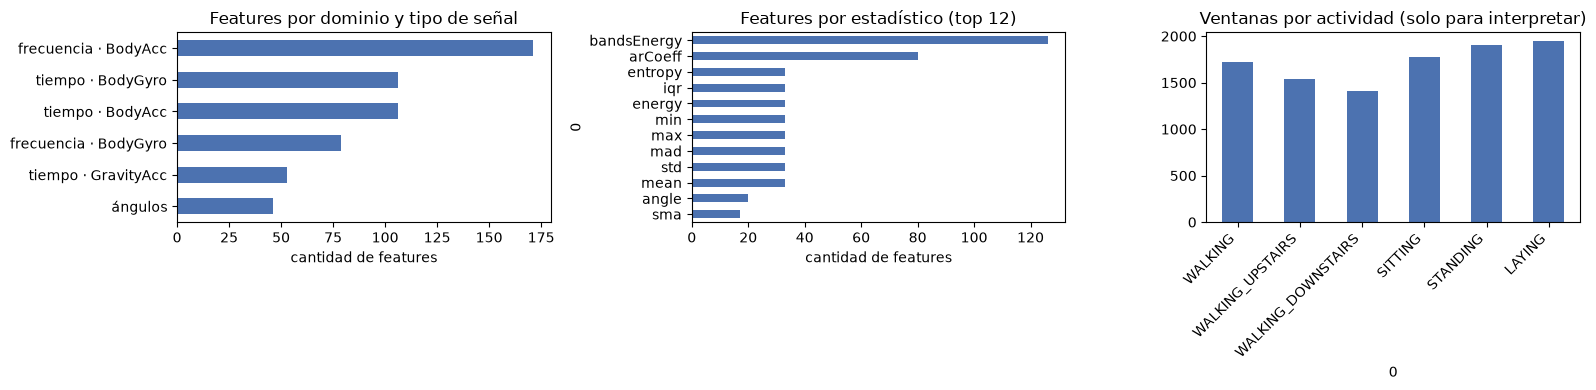

In [5]:
familias = pd.Series(nombres).str.extract(r'^([tf])(Body|Gravity)(Acc|Gyro)')
familias = (familias[0].map({'t': 'tiempo', 'f': 'frecuencia'}) + ' · ' + familias[1] + familias[2]).fillna('ángulos')
estadistico = pd.Series(nombres).str.extract(r'-(\w+)\(')[0].fillna('angle')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

familias.value_counts().sort_values().plot.barh(ax=axes[0], color='#4c72b0')
axes[0].set_title('Features por dominio y tipo de señal')
axes[0].set_xlabel('cantidad de features')

estadistico.value_counts().head(12).sort_values().plot.barh(ax=axes[1], color='#4c72b0')
axes[1].set_title('Features por estadístico (top 12)')
axes[1].set_xlabel('cantidad de features')

y.value_counts().reindex(ORDEN_ACT).plot.bar(ax=axes[2], color='#4c72b0')
axes[2].set_title('Ventanas por actividad (solo para interpretar)')
axes[2].tick_params(axis='x', rotation=45)
for lbl in axes[2].get_xticklabels():
    lbl.set_ha('right')

plt.tight_layout()
plt.show()

Las clases están balanceadas (1.400 a 1.950 ventanas cada una).

Dos features con significado físico claro:

- `tBodyAcc-std()-X`: variabilidad de la aceleración → nivel de movimiento.
- `tGravityAcc-mean()-X`: gravedad sobre el eje X → orientación del cuerpo.

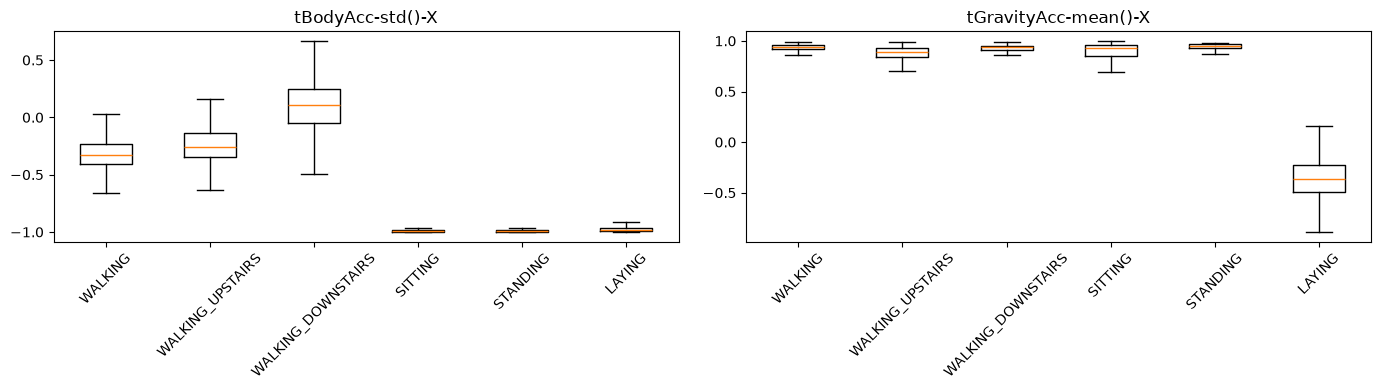

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['tBodyAcc-std()-X', 'tGravityAcc-mean()-X']):
    ax.boxplot([X.loc[y == a, col] for a in ORDEN_ACT], tick_labels=ORDEN_ACT, showfliers=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

La primera separa dinámicas de estáticas; la segunda separa `LAYING` del resto. Ambas anticipan las hipótesis.

Además hay mucha redundancia entre features (variantes de la misma señal):

In [7]:
corr = X.corr().abs().values
pares_altos = (np.triu(corr, k=1) > 0.9).sum()
total_pares = X.shape[1] * (X.shape[1] - 1) // 2
print(f"Pares de features con |correlación| > 0.9: {pares_altos} de {total_pares} ({pares_altos/total_pares:.1%})")

Pares de features con |correlación| > 0.9: 8093 de 157080 (5.2%)


### 2.2 Preprocesamiento

- No hace falta generar embeddings: los datos ya son vectores numéricos.
- No hay faltantes.
- Se **estandariza** (media 0, desvío 1), porque PCA y el clustering son sensibles a la escala.

La etiqueta y el sujeto quedan fuera de `X`.

In [8]:
X_std = StandardScaler().fit_transform(X)
print(X_std.shape)

(10299, 561)


## 3. Reducción de dimensionalidad y clustering

### 3.a PCA

Con 561 features muy correlacionadas, PCA es una buena opción para comprimir la información. Primero se ajusta completo para ver la varianza acumulada.

80% de la varianza -> 27 componentes
90% de la varianza -> 65 componentes
95% de la varianza -> 104 componentes
99% de la varianza -> 182 componentes


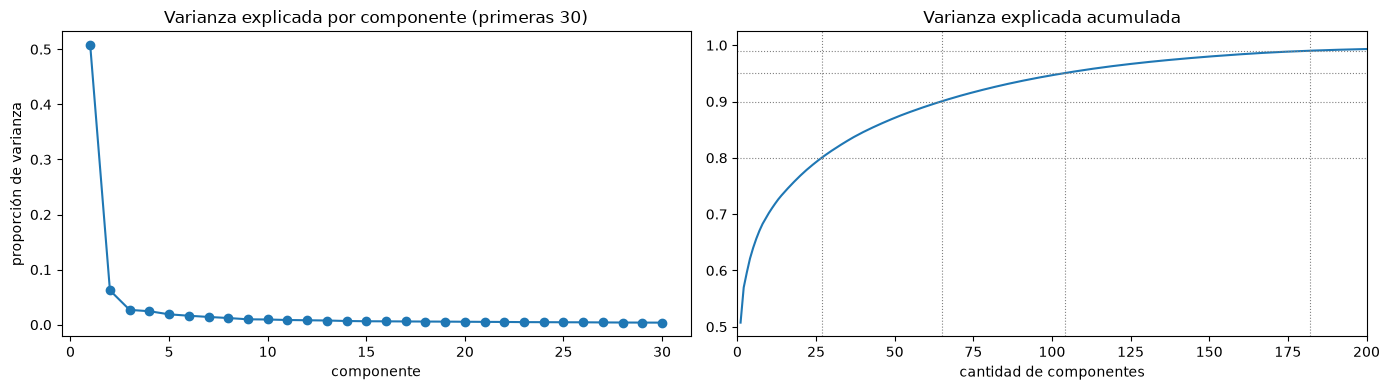

In [9]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_std)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

umbrales = [0.80, 0.90, 0.95, 0.99]
n_por_umbral = {u: int(np.argmax(var_acum >= u) + 1) for u in umbrales}
for u, n in n_por_umbral.items():
    print(f"{u:.0%} de la varianza -> {n} componentes")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.arange(1, 31), pca_full.explained_variance_ratio_[:30], marker='o')
axes[0].set_title('Varianza explicada por componente (primeras 30)')
axes[0].set_xlabel('componente')
axes[0].set_ylabel('proporción de varianza')

axes[1].plot(np.arange(1, len(var_acum) + 1), var_acum)
for u, n in n_por_umbral.items():
    axes[1].axhline(u, color='gray', ls=':', lw=0.8)
    axes[1].axvline(n, color='gray', ls=':', lw=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('cantidad de componentes')
plt.tight_layout()
plt.show()

- La **PC1 sola explica ~51%** de la varianza.
- Se conservan **65 componentes (90% de la varianza)**: 561 → 65 dimensiones. Llegar al 95% requiere 104 componentes por solo 5 puntos más.

In [10]:
N_COMP = n_por_umbral[0.90]
pca = PCA(n_components=N_COMP, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_std)
print(f"Dataset reducido: {Z.shape} — varianza conservada: {pca.explained_variance_ratio_.sum():.1%}")

Dataset reducido: (10299, 65) — varianza conservada: 90.0%


Features con mayor peso en PC1 y PC2:

In [11]:
cargas = pd.DataFrame(pca.components_[:3].T, index=nombres, columns=['PC1', 'PC2', 'PC3'])
for pc in ['PC1', 'PC2']:
    top = cargas[pc].abs().sort_values(ascending=False).head(8).index
    print(f"--- {pc} ---")
    print(cargas.loc[top, pc].round(3).to_string())
    print()

--- PC1 ---
nombre
fBodyAcc-sma()                0.059
fBodyAccJerk-sma()            0.059
fBodyGyro-sma()               0.059
tBodyAccJerk-sma()            0.059
tBodyAccJerkMag-sma()         0.058
tBodyAccJerkMag-mean()        0.058
fBodyBodyAccJerkMag-mean()    0.058
fBodyBodyAccJerkMag-sma()     0.058

--- PC2 ---
nombre
fBodyAcc-meanFreq()-Z        0.124
tBodyGyroMag-arCoeff()1      0.121
fBodyAccMag-meanFreq()       0.120
tGravityAcc-arCoeff()-Z,1    0.120
tBodyAccMag-arCoeff()1       0.119
tGravityAccMag-arCoeff()1    0.119
tGravityAcc-arCoeff()-Z,2   -0.119
tGravityAcc-arCoeff()-Z,3    0.118



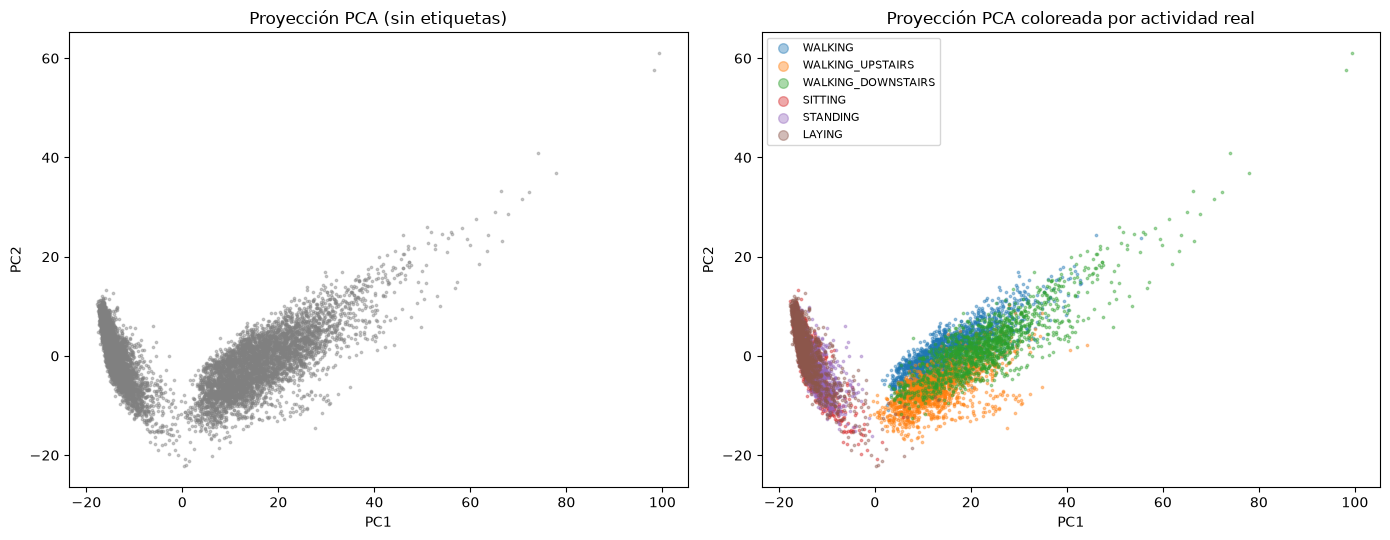

In [12]:
colores_act = dict(zip(ORDEN_ACT, plt.cm.tab10.colors[:6]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(Z[:, 0], Z[:, 1], s=3, alpha=0.4, color='gray')
axes[0].set_title('Proyección PCA (sin etiquetas)')
for a in ORDEN_ACT:
    m = (y == a).values
    axes[1].scatter(Z[m, 0], Z[m, 1], s=3, alpha=0.4, color=colores_act[a], label=a)
axes[1].set_title('Proyección PCA coloreada por actividad real')
axes[1].legend(markerscale=4, fontsize=8)
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

- **PC1** = intensidad del movimiento (promedia features de magnitud como `sma` y jerk).
- **PC2** = ritmo de la señal (frecuencia media, coeficientes autorregresivos).

Sin etiquetas ya se ven **dos nubes** a lo largo de PC1; al colorear, son estáticas (izquierda) y dinámicas (derecha), lo que apoya la hipótesis 1. `SITTING` y `STANDING` se superponen, y las formas de caminar se solapan.

### 3.b Clustering

Se prueban tres algoritmos sobre las 65 componentes:

| Algoritmo | Idea |
|---|---|
| **K-Means** | Grupos alrededor de un centroide, de tamaño similar |
| **Ward (jerárquico)** | Une grupos minimizando la varianza interna; da una jerarquía |
| **DBSCAN** | Grupos = regiones densas; detecta ruido |

#### Elección de k

Se recorre k = 2..10 con métricas internas (sin etiquetas): inercia, Silhouette (↑), Davies-Bouldin (↓) y Calinski-Harabasz (↑).

In [13]:
def metricas_internas(Z, labels):
    return {
        'silhouette': silhouette_score(Z, labels, sample_size=4000, random_state=RANDOM_STATE),
        'davies_bouldin': davies_bouldin_score(Z, labels),
        'calinski_harabasz': calinski_harabasz_score(Z, labels),
    }

filas = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    filas.append({'algoritmo': 'K-Means', 'k': k, 'inercia': km.inertia_, **metricas_internas(Z, km.labels_)})
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(Z)
    filas.append({'algoritmo': 'Ward', 'k': k, 'inercia': np.nan, **metricas_internas(Z, ward.labels_)})

res_k = pd.DataFrame(filas)
res_k.pivot(index='k', columns='algoritmo', values=['silhouette', 'davies_bouldin', 'calinski_harabasz']).round(3)

silhouette        davies_bouldin        calinski_harabasz          
algoritmo    K-Means   Ward        K-Means   Ward           K-Means      Ward
k                                                                            
2              0.439  0.438          0.961  0.962          9560.024  9532.153
3              0.353  0.305          1.597  1.771          6266.725  5875.211
4              0.181  0.304          2.057  1.782          4657.618  4306.290
5              0.159  0.123          2.138  2.178          3860.248  3496.015
6              0.140  0.137          2.068  2.044          3287.027  3021.272
7              0.119  0.117          2.285  2.489          2867.631  2653.975
8              0.102  0.083          2.251  2.500          2571.478  2373.482
9              0.106  0.085          2.243  2.518          2346.490  2153.323
10             0.108  0.089          2.129  2.388          2152.568  1978.257

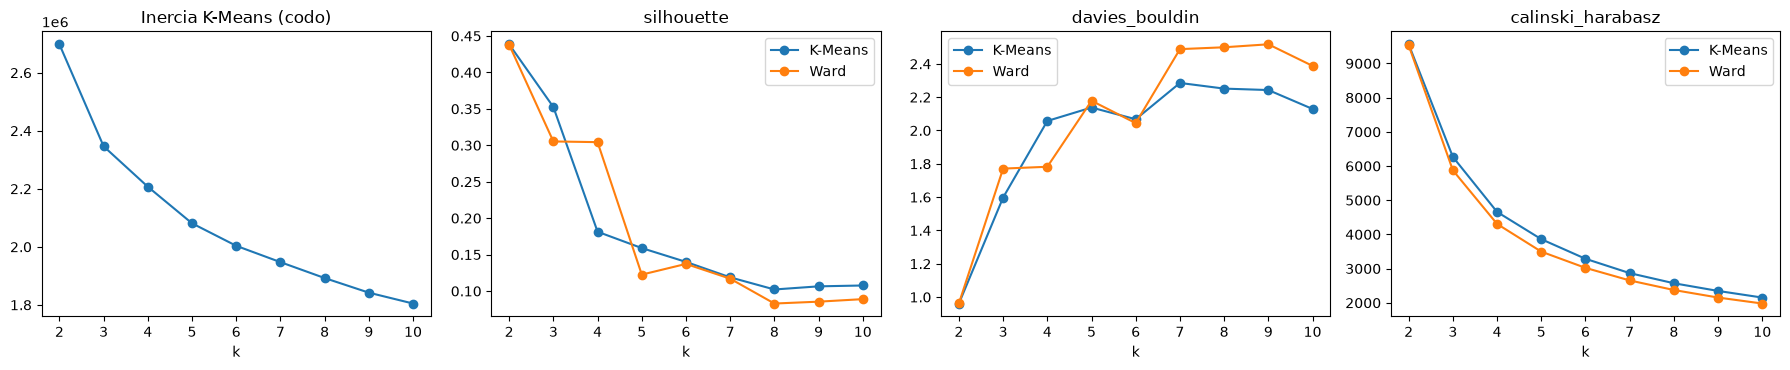

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
km_res = res_k[res_k['algoritmo'] == 'K-Means']
axes[0].plot(km_res['k'], km_res['inercia'], marker='o')
axes[0].set_title('Inercia K-Means (codo)')
for ax, met in zip(axes[1:], ['silhouette', 'davies_bouldin', 'calinski_harabasz']):
    for alg, g in res_k.groupby('algoritmo'):
        ax.plot(g['k'], g[met], marker='o', label=alg)
    ax.set_title(met)
    ax.legend()
for ax in axes:
    ax.set_xlabel('k')
plt.tight_layout()
plt.show()

Todas las métricas indican que **k = 2 es la mejor partición**: hay dos grandes grupos muy separados. Con más clusters la calidad cae porque los subgrupos internos están poco separados.

Dendrograma de Ward (muestra de 3.000 puntos):

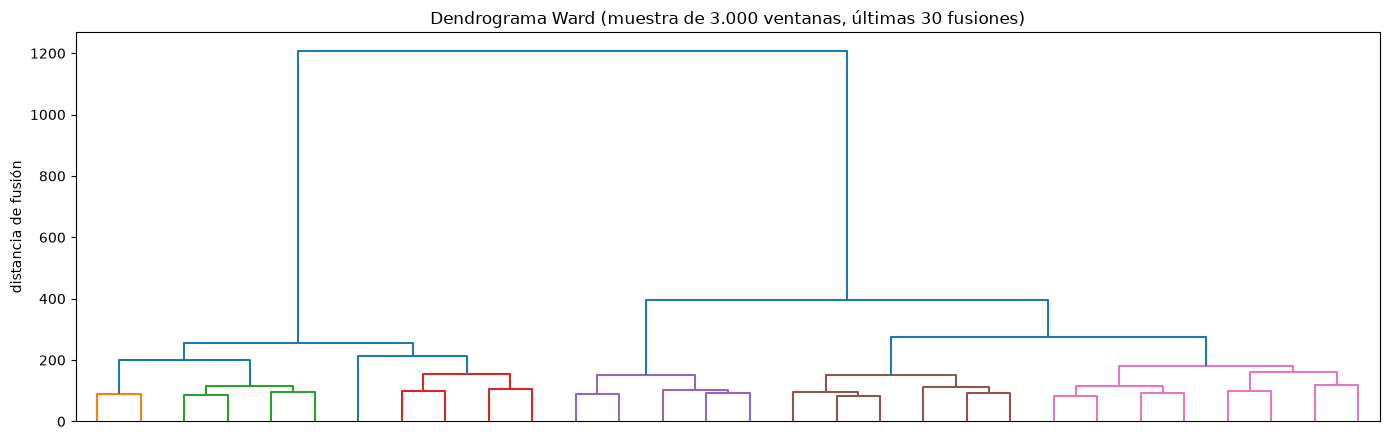

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
idx_muestra = rng.choice(len(Z), size=3000, replace=False)
L = linkage(Z[idx_muestra], method='ward')

fig, ax = plt.subplots(figsize=(14, 4.5))
dendrogram(L, truncate_mode='lastp', p=30, ax=ax, color_threshold=L[-6, 2], no_labels=True)
ax.set_title('Dendrograma Ward (muestra de 3.000 ventanas, últimas 30 fusiones)')
ax.set_ylabel('distancia de fusión')
plt.tight_layout()
plt.show()

La última fusión ocurre a una distancia mucho mayor que el resto: confirma los dos grandes grupos.

Se analizan dos niveles:

- **k = 2**: el óptimo según las métricas.
- **k = 6**: igual al número de actividades, para ver la estructura dentro de cada grupo (no usa las etiquetas de cada ventana).

In [16]:
modelos = {
    'K-Means k=2': KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE),
    'Ward k=2': AgglomerativeClustering(n_clusters=2, linkage='ward'),
    'K-Means k=6': KMeans(n_clusters=6, n_init=10, random_state=RANDOM_STATE),
    'Ward k=6': AgglomerativeClustering(n_clusters=6, linkage='ward'),
}
etiquetas = {nombre: m.fit_predict(Z) for nombre, m in modelos.items()}

#### DBSCAN

`eps` se elige con la curva de distancia al 10° vecino.

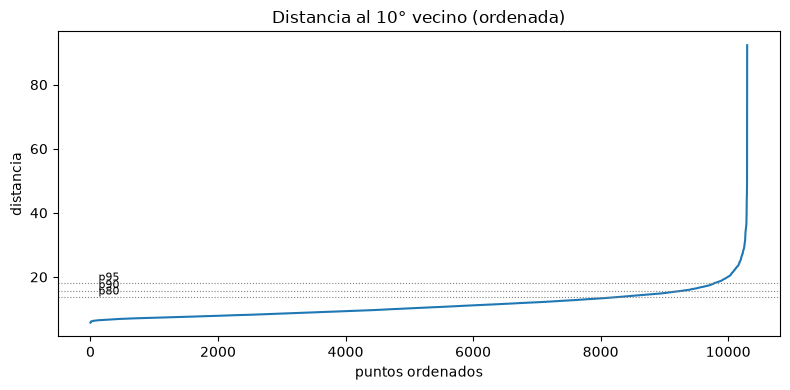

,percentil_eps,eps,n_clusters,% ruido,tamaños
0,0.70,12.33,8,20.1,"[5365, 2747, 28, 27, 20, 19]"
1,0.80,13.68,4,11.3,"[9086, 32, 11, 9]"
2,0.85,14.50,4,8.0,"[9403, 39, 16, 12]"
3,0.90,15.66,3,5.3,"[9689, 45, 16]"
4,0.95,18.04,1,2.6,[10034]


In [17]:
MIN_SAMPLES = 10
dist_k = np.sort(NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z).kneighbors(Z)[0][:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dist_k)
for q in [0.80, 0.90, 0.95]:
    ax.axhline(np.quantile(dist_k, q), color='gray', ls=':', lw=0.8)
    ax.text(0, np.quantile(dist_k, q), f'  p{int(q*100)}', va='bottom', fontsize=8)
ax.set_title(f'Distancia al {MIN_SAMPLES}° vecino (ordenada)')
ax.set_xlabel('puntos ordenados')
ax.set_ylabel('distancia')
plt.tight_layout()
plt.show()

filas = []
for q in [0.70, 0.80, 0.85, 0.90, 0.95]:
    eps = np.quantile(dist_k, q)
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Z)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)
    tamanios = pd.Series(lab[lab != -1]).value_counts().tolist()
    filas.append({'percentil_eps': q, 'eps': round(eps, 2), 'n_clusters': n_cl,
                  '% ruido': round((lab == -1).mean() * 100, 1), 'tamaños': tamanios[:6]})
pd.DataFrame(filas)

DBSCAN es muy sensible a `eps`:

- Percentil 70: dos grupos grandes, pero **20% de ruido**.
- Percentil 80 o más: todo se une en un solo cluster.

La densidad es muy distinta entre la nube estática (compacta) y la dinámica (dispersa), así que ningún `eps` funciona bien para ambas. Se usa el percentil 70 para comparar.

In [18]:
EPS = np.quantile(dist_k, 0.70)
etiquetas['DBSCAN'] = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(Z)
print(pd.Series(etiquetas['DBSCAN']).value_counts().rename('tamaño').to_string())

 0    5365
 1    2747
-1    2069
 4      28
 3      27
 7      20
 2      19
 6      15
 5       9


### 3.c Evaluación y comparación

- **Métricas internas**: calidad geométrica, sin etiquetas.
- **Métricas externas** (ARI, AMI): solo para evaluar a posteriori contra la actividad real y contra dinámica/estática.

En DBSCAN las métricas internas excluyen el ruido.

In [19]:
dinamica = y.isin(['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']).map({True: 'DINÁMICA', False: 'ESTÁTICA'})

filas = []
for nombre, lab in etiquetas.items():
    m = lab != -1
    fila = {'solución': nombre, 'n_clusters': len(set(lab[m])), '% ruido': round((~m).mean() * 100, 1)}
    fila.update(metricas_internas(Z[m], lab[m]) if len(set(lab[m])) > 1 else
                {'silhouette': np.nan, 'davies_bouldin': np.nan, 'calinski_harabasz': np.nan})
    fila['ARI actividad'] = adjusted_rand_score(y, lab)
    fila['AMI actividad'] = adjusted_mutual_info_score(y, lab)
    fila['ARI dinámica/estática'] = adjusted_rand_score(dinamica, lab)
    filas.append(fila)

comparacion = pd.DataFrame(filas).set_index('solución').round(3)
comparacion

,n_clusters,% ruido,silhouette,davies_bouldin,calinski_harabasz,ARI actividad,AMI actividad,ARI dinámica/estática
solución,,,,,,,,
K-Means k=2,2,0.0,0.439,0.961,9560.024,0.330,0.545,0.991
Ward k=2,2,0.0,0.438,0.962,9532.153,0.333,0.557,1.000
K-Means k=6,6,0.0,0.140,2.068,3287.027,0.420,0.559,0.393
Ward k=6,6,0.0,0.137,2.044,3021.272,0.494,0.622,0.471
DBSCAN,8,20.1,0.321,1.316,1323.303,0.322,0.474,0.722


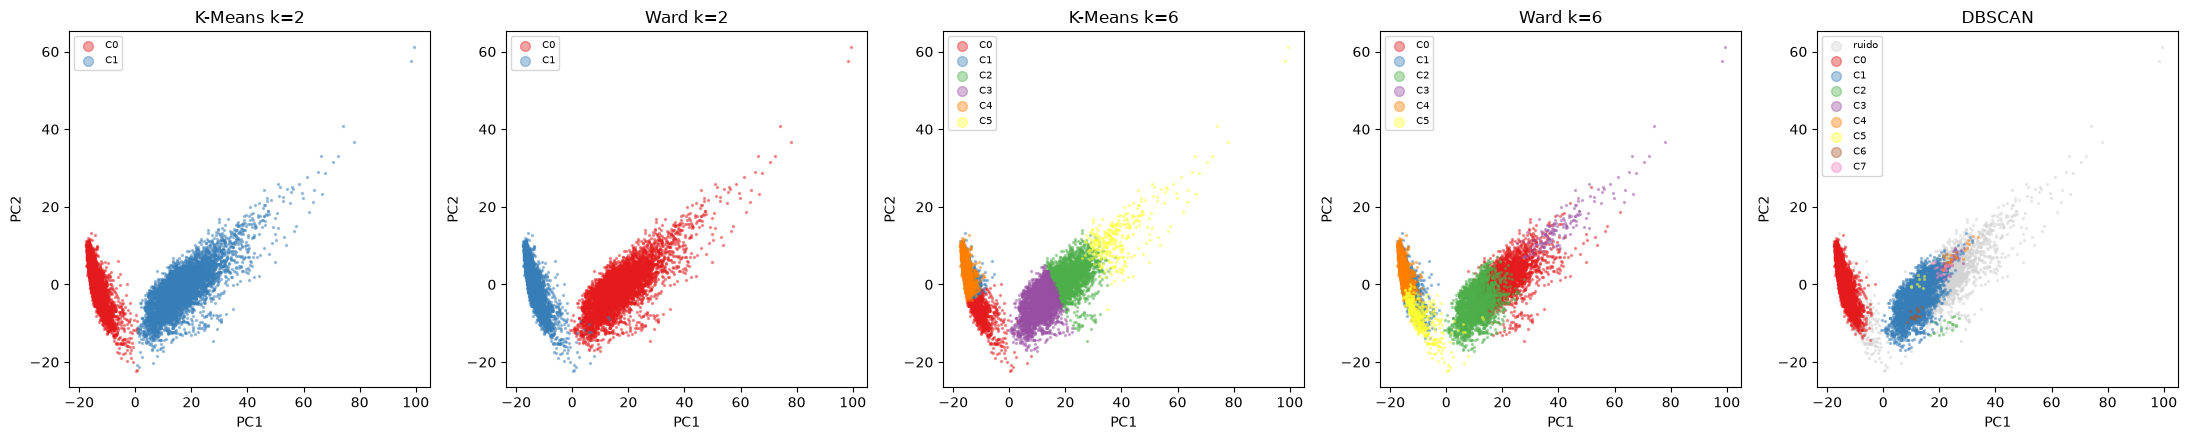

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (nombre, lab) in zip(axes, etiquetas.items()):
    for c in sorted(set(lab)):
        m = lab == c
        ax.scatter(Z[m, 0], Z[m, 1], s=2, alpha=0.4,
                   color='lightgray' if c == -1 else plt.cm.Set1(c % 9),
                   label='ruido' if c == -1 else f'C{c}')
    ax.set_title(nombre)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=5, fontsize=7)
plt.tight_layout()
plt.show()

**Resultados**

- **k = 2**: K-Means y Ward separan casi perfectamente dinámicas de estáticas (ARI 0,99 y 1,00). Hipótesis 1 confirmada.
- **k = 6**: baja la Silhouette, pero mejora la relación con las actividades. **Ward supera a K-Means** (ARI 0,49 vs 0,42).
- **DBSCAN**: descartado. Deja 20% de ruido y solo reproduce, peor, la división de k = 2.

Ward funciona mejor porque las nubes tienen tamaños y densidades distintas; K-Means tiende a cortar grupos en partes iguales.

**Solución elegida: Ward con k = 6.** Incluye la división de k = 2 y además muestra estructura dentro de cada grupo.

In [21]:
labels_sel = etiquetas['Ward k=6']
labels_k2 = etiquetas['Ward k=2']
print("Ward k=6 anidado dentro de Ward k=2 (filas: k=6, columnas: k=2):")
pd.crosstab(pd.Series(labels_sel, name='Ward k=6'), pd.Series(labels_k2, name='Ward k=2'))

Ward k=6 anidado dentro de Ward k=2 (filas: k=6, columnas: k=2):


Ward k=2,0,1
Ward k=6,,
0,2281,0
1,0,3465
2,2241,0
3,150,0
4,0,1675
5,0,487


Cada cluster de k = 6 queda dentro de uno solo de los dos grandes grupos.

### 3.d Interpretación de los clusters (Ward, k = 6)

#### Composición según la actividad real

In [22]:
tabla = pd.crosstab(pd.Series(labels_sel, name='cluster'), pd.Series(y, name='actividad'))[ORDEN_ACT]
tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

resumen = pd.DataFrame({
    'tamaño': tabla.sum(axis=1),
    'actividad dominante': tabla.idxmax(axis=1),
    '% dominante': tabla_pct.max(axis=1).round(1),
    'macro-grupo': pd.Series(labels_k2, name='k2').groupby(labels_sel).first()
})
print(resumen)
tabla

   tamaño actividad dominante  % dominante  macro-grupo
0    2281  WALKING_DOWNSTAIRS         50.2            0
1    3465            STANDING         52.9            1
2    2241    WALKING_UPSTAIRS         53.9            0
3     150  WALKING_DOWNSTAIRS         82.7            0
4    1675              LAYING         95.8            1
5     487              LAYING         54.6            1


actividad,WALKING,WALKING_UPSTAIRS,WALKING_DOWNSTAIRS,SITTING,STANDING,LAYING
cluster,,,,,,
0,800,337,1144,0,0,0
1,0,0,0,1559,1832,74
2,896,1207,138,0,0,0
3,26,0,124,0,0,0
4,0,0,0,71,0,1604
5,0,0,0,147,74,266


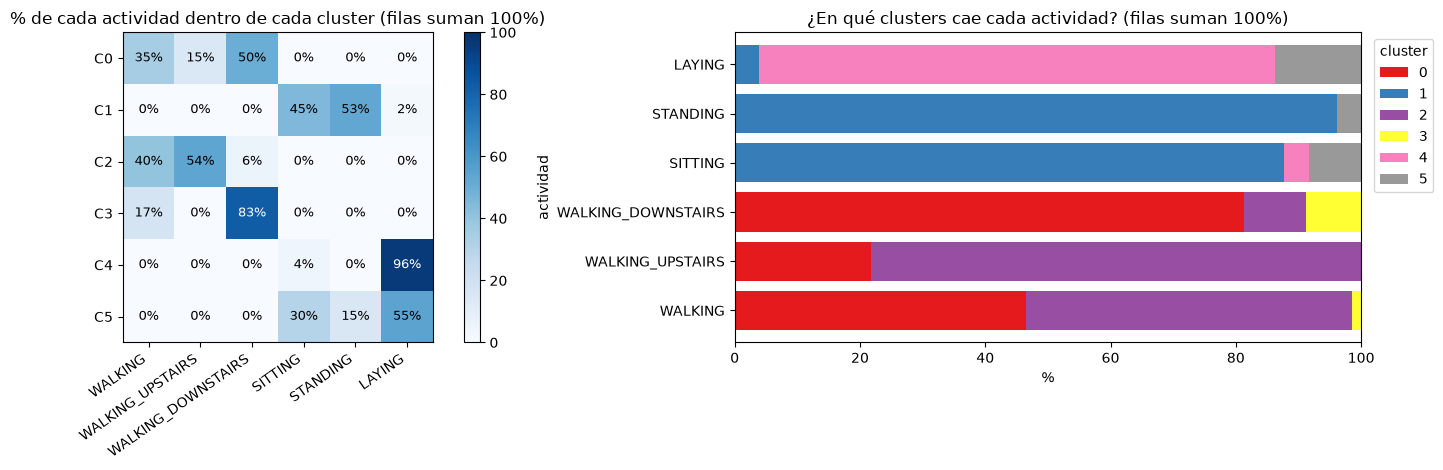

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

im = axes[0].imshow(tabla_pct.values, cmap='Blues', vmin=0, vmax=100)
axes[0].set_xticks(range(6), ORDEN_ACT, rotation=35, ha='right')
axes[0].set_yticks(range(6), [f'C{c}' for c in tabla_pct.index])
for i in range(6):
    for j in range(6):
        v = tabla_pct.values[i, j]
        axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=9,
                     color='white' if v > 60 else 'black')
axes[0].set_title('% de cada actividad dentro de cada cluster (filas suman 100%)')
fig.colorbar(im, ax=axes[0], fraction=0.04)

tabla_col = tabla.div(tabla.sum(axis=0), axis=1) * 100
tabla_col.T.plot.barh(stacked=True, ax=axes[1], colormap='Set1', width=0.8)
axes[1].set_title('¿En qué clusters cae cada actividad? (filas suman 100%)')
axes[1].set_xlabel('%')
axes[1].legend(title='cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

- **Dinámicas y estáticas nunca se mezclan**: C0, C2, C3 son dinámicas; C1, C4, C5 estáticas.
- **`LAYING` se identifica bien**: C4 es 96% `LAYING` (hipótesis 2).
- **`SITTING` y `STANDING` se mezclan** en C1 (53% / 45%) (hipótesis 2).
- **Las formas de caminar se mezclan** (hipótesis 3): C0 tiene sobre todo bajada de escaleras y C2 subida; `WALKING` se reparte entre ambos.
- **C3 y C5** son grupos chicos que no corresponden a una actividad (ver abajo).

No hay correspondencia 1 a 1 con las actividades, pero la estructura es coherente: primero intensidad de movimiento, después postura.

#### ¿Qué features distinguen a cada cluster?

Valor medio estandarizado de algunas features interpretables:

| Feature | Significado |
|---|---|
| `tBodyAcc-std()-X`, `tBodyAccMag-mean()` | Intensidad del movimiento |
| `fBodyAcc-meanFreq()-X` | Frecuencia media del movimiento |
| `tBodyGyro-std()-Z` | Variabilidad de la rotación |
| `tBodyAccJerk-std()-Z` | Brusquedad (golpes de pisada) |
| `tGravityAcc-mean()-X/Y/Z`, `angle(X,gravityMean)` | Orientación / postura |

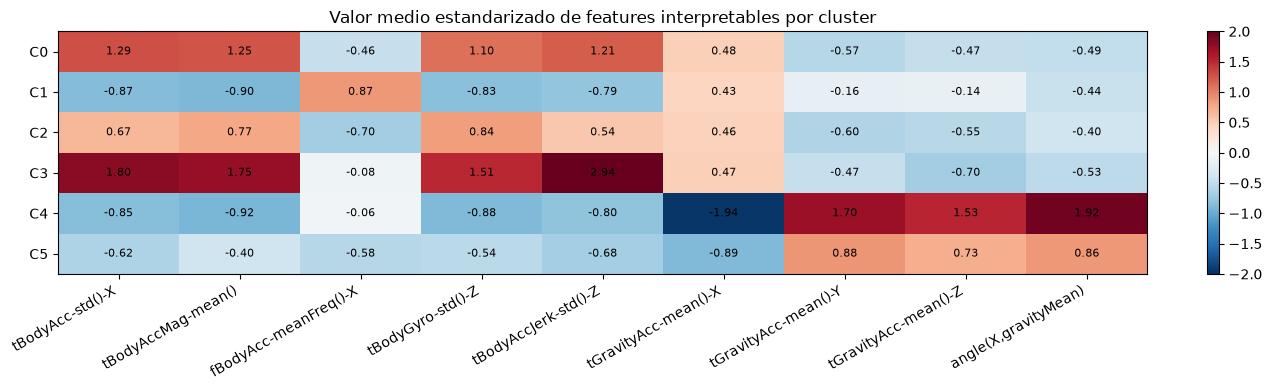

In [24]:
feats_interp = ['tBodyAcc-std()-X', 'tBodyAccMag-mean()', 'fBodyAcc-meanFreq()-X', 'tBodyGyro-std()-Z',
                'tBodyAccJerk-std()-Z', 'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z',
                'angle(X,gravityMean)']
X_std_df = pd.DataFrame(X_std, columns=nombres)
perfil = X_std_df[feats_interp].groupby(labels_sel).mean()
perfil.index = [f'C{c}' for c in perfil.index]

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(perfil.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(feats_interp)), feats_interp, rotation=30, ha='right')
ax.set_yticks(range(len(perfil)), perfil.index)
for i in range(perfil.shape[0]):
    for j in range(perfil.shape[1]):
        ax.text(j, i, f'{perfil.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Valor medio estandarizado de features interpretables por cluster')
fig.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

Features que más separan a cada cluster del resto:

In [25]:
medias_cluster = X_std_df.groupby(labels_sel).mean()
for c in medias_cluster.index:
    top = medias_cluster.loc[c].abs().sort_values(ascending=False).head(5).index
    detalle = ', '.join(f"{f} ({medias_cluster.loc[c, f]:+.2f})" for f in top)
    print(f"C{c}: {detalle}")

C0: tBodyAccJerkMag-mad() (+1.36), tBodyAccJerkMag-std() (+1.35), fBodyBodyAccJerkMag-std() (+1.35), fBodyBodyAccJerkMag-mad() (+1.35), fBodyBodyAccJerkMag-sma() (+1.35)
C1: fBodyAcc-entropy()-X (-0.95), tBodyAcc-entropy()-X (-0.95), tBodyAcc-arCoeff()-X,1 (+0.92), tBodyAccJerk-entropy()-X (-0.92), fBodyAccJerk-entropy()-X (-0.90)
C2: tBodyAccJerk-entropy()-X (+1.04), fBodyAccJerk-meanFreq()-Z (-1.00), tBodyGyro-arCoeff()-Z,1 (-1.00), tBodyAccJerk-entropy()-Y (+1.00), tBodyGyroJerk-entropy()-Z (+0.99)
C3: fBodyAccJerk-bandsEnergy()-25,48_423 (+5.00), fBodyAcc-bandsEnergy()-25,48_344 (+4.98), fBodyAccJerk-bandsEnergy()-25,32_413 (+4.97), fBodyAcc-bandsEnergy()-25,32_334 (+4.95), fBodyGyro-bandsEnergy()-25,32_478 (+4.84)
C4: tGravityAcc-max()-X (-1.97), tGravityAcc-energy()-X (-1.97), tGravityAcc-mean()-X (-1.94), angle(X,gravityMean) (+1.92), tGravityAcc-min()-X (-1.92)
C5: tGravityAcc-std()-X (+2.34), tGravityAcc-mad()-X (+2.29), tGravityAcc-std()-Z (+2.26), tGravityAcc-std()-Y (+2.24)

| Cluster | Qué lo distingue | Interpretación |
|---|---|---|
| **C0** | Movimiento intenso | Caminar con impactos fuertes (bajar escaleras) |
| **C2** | Movimiento moderado | Caminar suave (subir escaleras) |
| **C3** | Energía muy alta en frecuencias altas | Pisadas muy bruscas |
| **C1** | Sin movimiento, cuerpo vertical | Sentado o parado |
| **C4** | Gravedad rotada ~90° | Acostado |
| **C5** | Poco movimiento, pero la gravedad varía dentro de la ventana | **Cambios de postura** (acostarse / levantarse) |

**C5** es lo más interesante: el dataset no tiene etiqueta de "transición", pero el clustering encuentra esas ventanas como un grupo propio.

#### Observaciones representativas

Las 3 ventanas más cercanas al centroide de cada cluster:

In [26]:
centroides = pd.DataFrame(Z).groupby(labels_sel).mean().values
filas = []
for c in range(6):
    idx = np.where(labels_sel == c)[0]
    d = np.linalg.norm(Z[idx] - centroides[c], axis=1)
    for i in idx[np.argsort(d)[:3]]:
        filas.append({'cluster': f'C{c}', 'ventana': i, 'actividad real': y[i], 'sujeto': sujeto[i],
                      **X.loc[i, ['tBodyAcc-std()-X', 'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y',
                                   'angle(X,gravityMean)']].round(3).to_dict()})
representativas = pd.DataFrame(filas).set_index(['cluster', 'ventana'])
representativas

actividad real  sujeto  tBodyAcc-std()-X  \
cluster ventana                                                 
C0      8668     WALKING_DOWNSTAIRS      12            -0.101   
        8665     WALKING_DOWNSTAIRS      12             0.025   
        4325                WALKING      21            -0.265   
C1      4252                SITTING      21            -0.995   
        3639               STANDING      19            -0.994   
        857                STANDING       5            -0.996   
C2      8691       WALKING_UPSTAIRS      12            -0.326   
        6440       WALKING_UPSTAIRS      28            -0.299   
        6448       WALKING_UPSTAIRS      28            -0.268   
C3      3923                WALKING      19             0.107   
        3924                WALKING      19            -0.027   
        3927                WALKING      19            -0.078   
C4      408                  LAYING       3            -0.993   
        6135                 LAYING      27            -0.982   
        7560                 LAYING       2            -0.990   
C5      2938                 LAYING      16            -0.932   
        7533                SITTING       2            -0.965   
        3825                SITTING      19            -0.930   

                 tGravityAcc-mean()-X  tGravityAcc-mean()-Y  \
cluster ventana                                               
C0      8668                    0.954                -0.173   
        8665                    0.958                -0.129   
        4325                    0.862                -0.369   
C1      4252                    0.973                -0.039   
        3639                    0.931                -0.277   
        857                     0.957                 0.000   
C2      8691                    0.926                -0.247   
        6440                    0.864                -0.325   
        6448                    0.850                -0.351   
C3      3923                    0.936                -0.194   
        3924                    0.936                -0.200   
        3927                    0.925                -0.190   
C4      408                    -0.327                 0.757   
        6135                   -0.526                 0.525   
        7560                   -0.459                 0.733   
C5      2938                   -0.102                 0.428   
        7533                    0.928                -0.105   
        3825                    0.192                 0.579   

                 angle(X,gravityMean)  
cluster ventana                        
C0      8668                   -0.812  
        8665                   -0.877  
        4325                   -0.593  
C1      4252                   -0.909  
        3639                   -0.716  
        857                    -0.846  
C2      8691                   -0.723  
        6440                   -0.606  
        6448                   -0.573  
C3      3923                   -0.755  
        3924                   -0.743  
        3927                   -0.767  
C4      408                     0.485  
        6135                    0.629  
        7560                    0.581  
C5      2938                    0.322  
        7533                   -0.722  
        3825                    0.106

- **C1**: sin movimiento y gravedad en X ≈ 0,95 (vertical). Mezcla `SITTING` y `STANDING`.
- **C4**: la gravedad pasa del eje X al Y: teléfono rotado (acostado).
- **C5**: gravedad en valores intermedios, entre vertical y horizontal.
- **C0, C2, C3**: movimiento creciente de C2 a C3. Las ventanas típicas de C3 son todas del sujeto 19.

#### ¿Los clusters agrupan por persona?

In [27]:
print(f"AMI(cluster, actividad) = {adjusted_mutual_info_score(y, labels_sel):.3f}")
print(f"AMI(cluster, sujeto)    = {adjusted_mutual_info_score(sujeto, labels_sel):.3f}")
print()

conc = pd.crosstab(labels_sel, sujeto)
conc_pct = conc.div(conc.sum(axis=1), axis=0)
top3 = conc_pct.apply(lambda r: r.sort_values(ascending=False).head(3).sum(), axis=1)
print("% del cluster que aportan sus 3 sujetos más frecuentes (con 30 sujetos, lo esperable sin sesgo es ~10%):")
print((top3 * 100).round(1).rename(lambda c: f'C{c}').to_string())

AMI(cluster, actividad) = 0.622
AMI(cluster, sujeto)    = 0.050

% del cluster que aportan sus 3 sujetos más frecuentes (con 30 sujetos, lo esperable sin sesgo es ~10%):
row_0
C0    18.4
C1    14.2
C2    22.0
C3    80.7
C4    16.2
C5    23.4


- Los clusters reflejan la **actividad** (AMI 0,62) y no al sujeto (AMI 0,05).
- **Excepción: C3**. El 81% de sus ventanas son de 3 sujetos: es un estilo de pisada individual, no una actividad.

Para validar que **C5 son transiciones**, se mide qué tan cerca están sus ventanas de un cambio de actividad:

In [28]:
act_arr = y.values
cambio = np.r_[False, act_arr[1:] != act_arr[:-1]] | np.r_[act_arr[:-1] != act_arr[1:], False]
print("% de ventanas pegadas (±1) a un cambio de actividad:")
print(pd.Series(cambio).groupby(labels_sel).mean().mul(100).round(1).rename(lambda c: f'C{c}').to_string())
print(f"Global: {cambio.mean()*100:.1f}%")

% de ventanas pegadas (±1) a un cambio de actividad:
C0     9.6
C1     5.5
C2     8.8
C3    13.3
C4     3.6
C5    22.6
Global: 7.7%


C5 está junto a un cambio de actividad el 22,6% de las veces, contra 7,7% en todo el dataset: confirma que captura **transiciones de postura**.

## 4. Visualización con UMAP

UMAP sobre los **datos originales estandarizados** (561 features). A diferencia de PCA, es no lineal y preserva vecindarios locales. Parámetros: `n_neighbors=30`, `min_dist=0.1`. La etiqueta solo se usa para colorear.

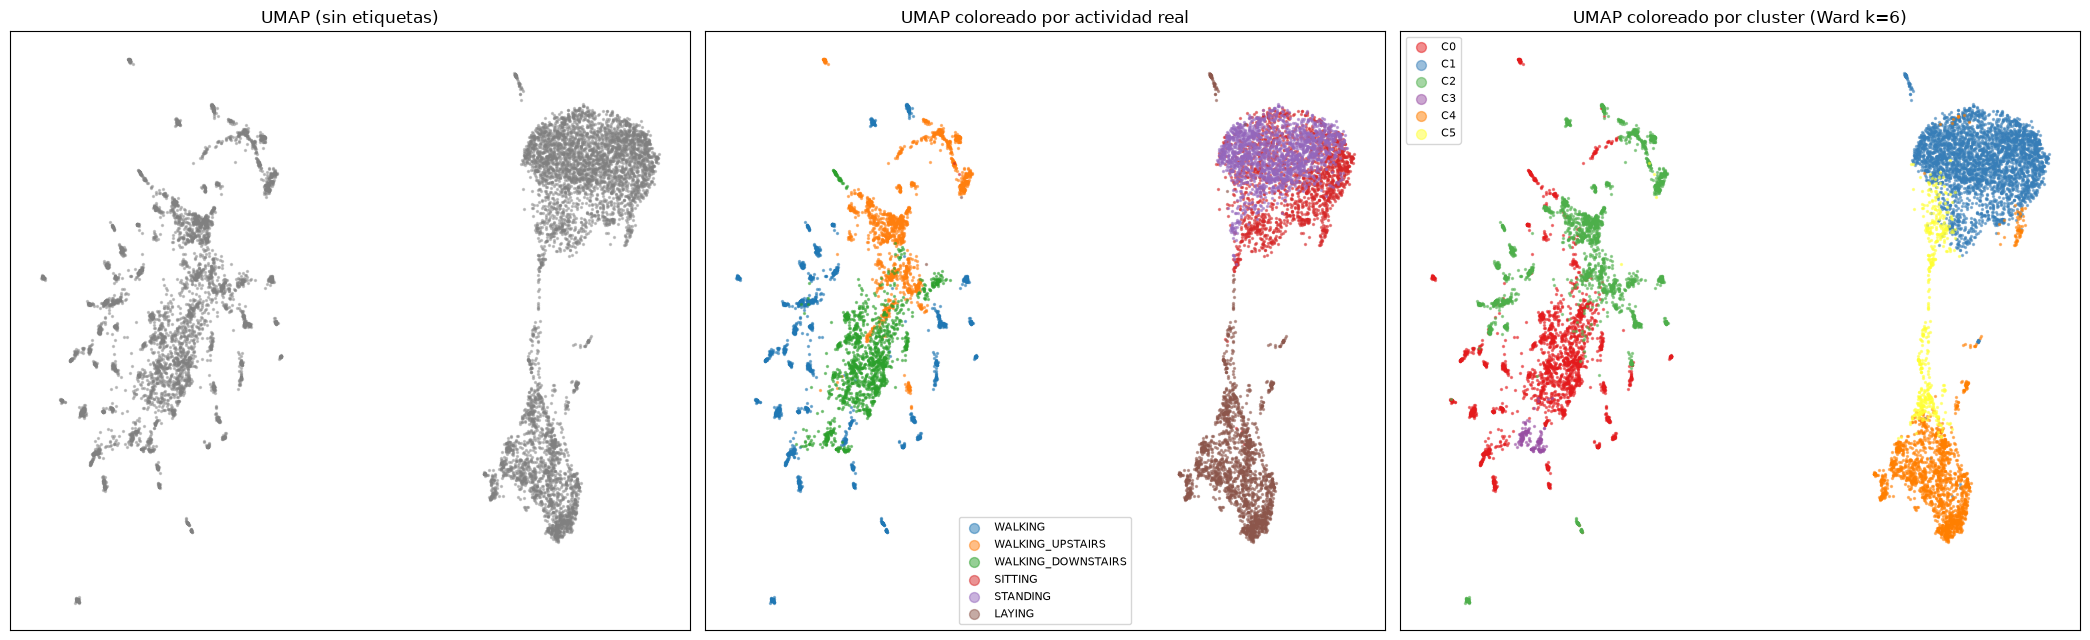

In [29]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
U = reducer.fit_transform(X_std)

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))

axes[0].scatter(U[:, 0], U[:, 1], s=2, alpha=0.4, color='gray')
axes[0].set_title('UMAP (sin etiquetas)')

for a in ORDEN_ACT:
    m = (y == a).values
    axes[1].scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=colores_act[a], label=a)
axes[1].set_title('UMAP coloreado por actividad real')
axes[1].legend(markerscale=5, fontsize=8)

for c in range(6):
    m = labels_sel == c
    axes[2].scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=plt.cm.Set1(c), label=f'C{c}')
axes[2].set_title('UMAP coloreado por cluster (Ward k=6)')
axes[2].legend(markerscale=5, fontsize=8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Densidad local en el mapa (1% menos denso marcado en rojo) y coloreo por sujeto:

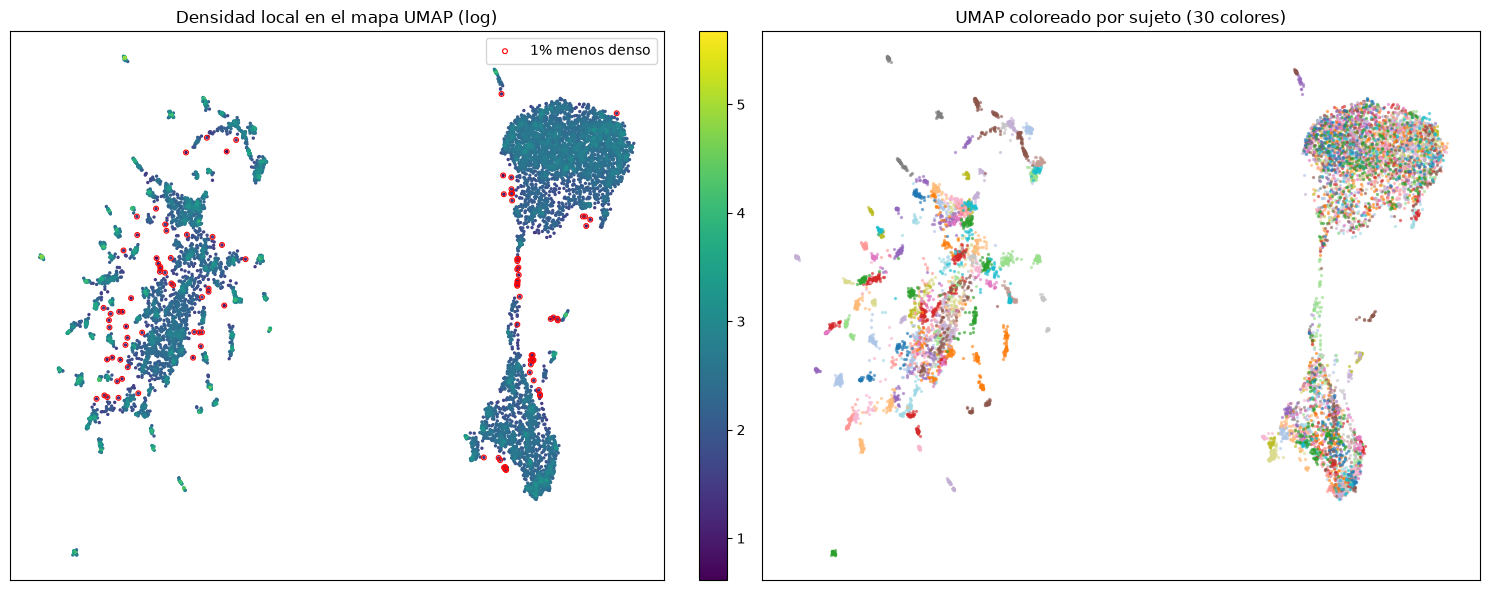

Actividad real de los puntos aislados:
0
LAYING                39
WALKING_DOWNSTAIRS    28
WALKING_UPSTAIRS      13
WALKING               12
SITTING                9
STANDING               2


In [30]:
d_umap = NearestNeighbors(n_neighbors=16).fit(U).kneighbors(U)[0][:, 1:].mean(axis=1)
densidad = 1 / d_umap
aislados = densidad < np.quantile(densidad, 0.01)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc = axes[0].scatter(U[:, 0], U[:, 1], s=2, c=np.log(densidad), cmap='viridis')
axes[0].scatter(U[aislados, 0], U[aislados, 1], s=12, facecolors='none', edgecolors='red', lw=0.8,
                label='1% menos denso')
axes[0].set_title('Densidad local en el mapa UMAP (log)')
axes[0].legend()
fig.colorbar(sc, ax=axes[0], fraction=0.04)

for s in sujeto.unique():
    m = (sujeto == s).values
    axes[1].scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=plt.cm.tab20(s % 20))
axes[1].set_title('UMAP coloreado por sujeto (30 colores)')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Actividad real de los puntos aislados:")
print(y[aislados].value_counts().to_string())

- **Dos regiones separadas**: dinámicas y estáticas, igual que con PCA y clustering.
- **Zona estática**: arriba `SITTING`/`STANDING` mezclados, abajo `LAYING`, unidos por un **puente poco denso** donde cae C5 (transiciones).
- **Zona dinámica**: muchas islas chicas que corresponden **a cada persona**. La forma de caminar de cada sujeto pesa casi tanto como la actividad; por eso el clustering no separa bien las tres formas de caminar.
- **Puntos aislados**: en el puente (`LAYING` en transición) y en la periferia dinámica (bajadas de escalera con impactos extremos).

UMAP aporta dos cosas que PCA no mostraba: el puente de transiciones y el efecto de la persona en las actividades dinámicas.

## 5. Conclusiones

1. La estructura principal es **dinámico vs estático**: aparece en PCA, en las métricas (k = 2), en el clustering (ARI = 1,00) y en UMAP.
2. PCA redujo de 561 a 65 dimensiones conservando el 90% de la varianza.
3. **Ward** fue el mejor algoritmo para k = 6; **DBSCAN** no sirvió por la densidad desigual.
4. `LAYING` se separa bien; `SITTING`/`STANDING` y las formas de caminar se mezclan. Las tres hipótesis se confirman.
5. El clustering encontró grupos que las etiquetas no tienen: **transiciones de postura (C5)** y un **estilo de pisada individual (C3)**.
6. En las actividades dinámicas, la **persona** es una fuente de variación importante.

**Para el dominio**: sin supervisión se distingue moverse vs no moverse y acostado vs erguido. Separar sentado de parado o las formas de caminar requiere supervisión, y conviene evaluar con personas no vistas.